<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/desafio_hidreletricas_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---



---



---


# **Desafio Hidrelétricas — Séries Temporais**


---


---


---




## **Objetivo do projeto**

Construir um pipeline de séries temporais para prever o valor futuro de sensores do tipo strain gauge em uma estrutura hidrelétrica.

**Em resumo:** vamos usar o histórico de leitura dos sensores para tentar prever o próximo valor medido.


---


## **Estratégia**

1. Entender o contexto do desafio.
2. Carregar os dados.
3. Entender a estrutura do dataset.
4. Transformar os sensores em colunas.
5. Tratar valores ausentes.
6. Criar janelas temporais.
7. Separar treino e teste respeitando o tempo.
8. Criar um baseline simples.
9. Treinar modelos LSTM e GRU.
10. Avaliar com MAE, RMSE, MAPE e R².
11. Gerar gráficos para explicar os resultados.
12. Comunicar a conclusão.


---


> **Ideia central:** em séries temporais, a ordem dos dados importa. Portanto, treinamos com o passado e testamos com o futuro.


---



---



# **Fase 1 — Entendimento do Negócio**


---



---


## **Pergunta a ser respondida**

> Com base no histórico dos sensores da hidrelétrica, conseguimos prever o próximo valor de medição?


---


## **Valor da solução**

> Uma previsão de sensores pode apoiar o monitoramento preventivo de estruturas, ajudando a perceber mudanças de comportamento ao longo do tempo. Em um ambiente real, isso poderia ser usado como apoio para alertas, dashboards e análise técnica.


---



---

# **Fase 2 — Entendimento dos Dados**


---



---


Nesta fase analisamos o arquivo `straingauge_raw.csv` para descobrir:

- qual coluna representa a data/hora;
- qual coluna identifica o sensor;
- qual coluna contém o valor medido;
- quantos sensores existem;
- se existem valores faltantes;
- qual é o período histórico disponível.


---



---

## **1. Instalação e importação das bibliotecas**


---



---



In [4]:
# Instala bibliotecas necessárias, caso não estejam instaladas
def biblioteca_esta_instalado(nome_biblioteca):
    try:
        __import__(nome_biblioteca)
        return True
    except ImportError:
        return False

if not biblioteca_esta_instalado('watermark'):
    !pip -q install watermark

if not biblioteca_esta_instalado('tensorflow'):
    !pip -q install tensorflow

if not biblioteca_esta_instalado('sklearn'): # scikit-learn is imported as sklearn
    !pip -q install scikit-learn

if not biblioteca_esta_instalado('matplotlib'):
    !pip -q install matplotlib

if not biblioteca_esta_instalado('pandas'):
    !pip -q install pandas

if not biblioteca_esta_instalado('numpy'):
    !pip -q install numpy

In [5]:
# Importa a biblioteca pandas, usada para ler, organizar e tratar tabelas.
import pandas as pd

# Importa a biblioteca numpy, usada para operações numéricas e matrizes.
import numpy as np

# Importa o matplotlib, usado para criar gráficos.
import matplotlib.pyplot as plt

# Importa o MinMaxScaler, usado para normalizar os dados entre 0 e 1.
from sklearn.preprocessing import MinMaxScaler

# Importa métricas para avaliar a qualidade das previsões.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importa o TensorFlow, biblioteca usada para redes neurais.
import tensorflow as tf

# Importa camadas usadas para construir redes LSTM e GRU.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define uma semente aleatória para tornar os resultados reprodutíveis.
np.random.seed(42)
tf.random.set_seed(42)

## **2. Carregamento dos dados**

In [53]:
# Define o caminho do arquivo CSV.
arquivo = "https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/refs/heads/main/aprendizado_profundo/series_temporais/Desafio/straingauge_raw.csv"

# Lê o arquivo CSV e transforma em um DataFrame do pandas.
df = pd.read_csv(arquivo)

# Mostra as 5 primeiras linhas para verificar se o arquivo foi carregado corretamente.
print("="*106)
print("                            Essas são as cinco primeiras linhas do dataset")
print("="*106)
display(df.head())
print("="*106)

print("\n")
print("="*42)
# Mostra o tamanho da base: número de linhas e colunas.
print(f"O dataset possui, {df.shape[0]} linhas e {df.shape[1]} colunas")
print("="*42)

print("\n")
print("="*78)
# Mostra os nomes das colunas.
print("                Listando as colunas e seus tipos no dataset")
print("="*78)
for i, col in enumerate(df.columns, start=1):
    print(f"A {i}ª coluna possui o nome {col} e o tipo {df[col].dtype}")
print("="*78)

                            Essas são as cinco primeiras linhas do dataset


,date_time_dimension_full_date,sensor_strain_gauge_raw_engineer_vw,sensor_strain_gauge_rawfksensor_id
0,2000-11-07 00:00:00,4418.4,1
1,2000-11-07 00:00:00,5510.2,22
2,2000-11-07 00:00:00,5463.4,21
3,2000-11-07 00:00:00,6469.1,20
4,2000-11-07 00:00:00,6481.3,19




O dataset possui, 30905 linhas e 3 colunas


                Listando as colunas e seus tipos no dataset
A 1ª coluna possui o nome date_time_dimension_full_date e o tipo object
A 2ª coluna possui o nome sensor_strain_gauge_raw_engineer_vw e o tipo float64
A 3ª coluna possui o nome sensor_strain_gauge_rawfksensor_id e o tipo int64


## **3. Padronização dos nomes e tipos**

In [77]:
# Renomeia as colunas para nomes mais simples.
df = df.rename(columns={
    "date_time_dimension_full_date": "data_hora",
    "sensor_strain_gauge_raw_engineer_vw": "valor_sensor",
    "sensor_strain_gauge_rawfksensor_id": "id_sensor"
})

# Converte a coluna de data e hora para o tipo datetime, permitindo ordenar, filtrar e analisar o tempo corretamente.
df["data_hora"] = pd.to_datetime(df["data_hora"])

# Ordena os dados por data e sensor, pois em séries temporais, manter a ordem do tempo é essencial.
df = df.sort_values(["data_hora", "id_sensor"]).reset_index(drop=True)

# Mostra as primeiras linhas após a padronização.
print("="*40)
print("   Primeiras linhas pós padronização")
print("="*40)
display(df.head())
print("="*40)

# Mostra um resumo da base após ajustes.
print("\n")
print("="*55)
print("            Resumo do dataset pós ajuste")
print("="*55)
print(f"O dataset possui a data inicial {df["data_hora"].min()} e a \ndata final {df["data_hora"].max()}, possui {df["id_sensor"].nunique()} sensores com\na quantidade de {df["data_hora"].nunique()} de datas/horários")
print("="*55)

   Primeiras linhas pós padronização


,data_hora,valor_sensor,id_sensor
0,2000-11-07,4418.4,1
1,2000-11-07,4477.2,2
2,2000-11-07,4473.4,3
3,2000-11-07,4475.6,4
4,2000-11-07,6454.4,5




            Resumo do dataset pós ajuste
O dataset possui a data inicial 2000-11-07 00:00:00 e a 
data final 2020-08-04 15:00:00, possui 24 sensores com
a quantidade de 4713 de datas/horários


## **4. Análise inicial**

Quantidade de valores ausentes em cada coluna


,coluna,quantidade,percentual
0,data_hora,0,0.000000
1,valor_sensor,13369,43.258372
2,id_sensor,0,0.000000




   Estatísticas básicas da 
   coluna valor do sensor


,estatística,valor
0,count,17536.000000
1,mean,5148.272229
2,std,640.252692
3,min,1979.500000
4,25%,4607.900000
5,50%,5190.000000
6,75%,5511.000000
7,max,9151.600000




                              Quantidade de medições por sensor


,total_registros,registros_validos,media,desvio_padrao,minimo,maximo
id_sensor,,,,,,
1,1260,744,4074.767782,138.602114,4000.61,4480.30
2,1260,744,5035.236747,257.067623,4417.50,5420.30
3,1260,745,4590.799289,46.714351,4222.90,4666.37
4,1260,744,4486.917177,20.856299,4414.10,4597.90
5,1260,745,4967.310644,604.751256,4500.05,6462.50
6,1260,717,5420.875258,405.229335,5134.72,6476.80
7,1312,713,5140.694544,293.242923,4785.60,8441.07
8,1312,756,5984.155384,147.975687,5266.00,9151.60
9,1305,746,5502.317882,38.825320,5048.90,5598.40




                                  Gráfico representando a quantidade de registros válidos por sensor


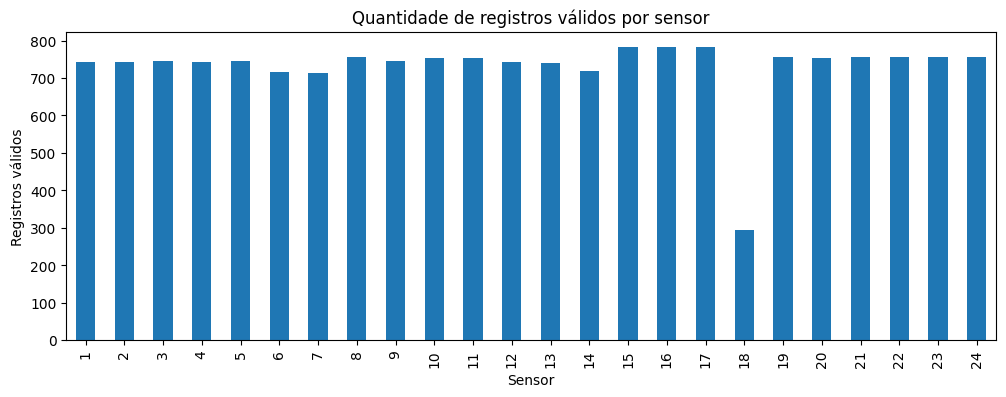

In [118]:
from os import name
# Conta quantos valores ausentes existem em cada coluna.
print("="*45)
print("Quantidade de valores ausentes em cada coluna")
print("="*45)

# Calcula a quantidade de valores ausentes por coluna.
dados_ausentes = df.isna().sum().reset_index()
dados_ausentes.columns = ['coluna', 'quantidade']

# Calcula o percentual de valores ausentes.
dados_ausentes['percentual'] = (dados_ausentes['quantidade'] / len(df)) * 100

display(dados_ausentes)
print("="*45)

print("\n")
print("="*30)
print("   Estatísticas básicas da \n   coluna valor do sensor")
print("="*30)
# Calcula estatísticas básicas da coluna de valor do sensor.
estatisticas_sensor = df["valor_sensor"].describe().reset_index()
estatisticas_sensor = estatisticas_sensor.rename(columns={
    "index": "estatística",
    "valor_sensor": "valor"
})
display(estatisticas_sensor)
print("="*30)

print("\n")

# Conta quantas medições existem por sensor.
print("="*90)
print("                              Quantidade de medições por sensor")
print("="*90)
contagem_por_sensor = df.groupby("id_sensor")["valor_sensor"].agg(
    total_registros="size",
    registros_validos="count",
    media="mean",
    desvio_padrao="std",
    minimo="min",
    maximo="max"
)

# Mostra a tabela resumida por sensor.
display(contagem_por_sensor)
print("="*90)

print("\n")

print("="*130)
print("                                  Gráfico representando a quantidade de registros válidos por sensor")
print("="*130)
# Cria um gráfico simples da quantidade de registros válidos por sensor.
contagem_por_sensor["registros_validos"].plot(kind="bar", figsize=(12, 4))
plt.title("Quantidade de registros válidos por sensor")
plt.xlabel("Sensor")
plt.ylabel("Registros válidos")
plt.show()
print("="*130)

## **5. Transformação para série multivariada**

In [131]:
# A tabela original está no formato longo (long), ou seja uma linha para cada sensor em cada data.
# Para LSTM/GRU multivariada, é mais prático transformar para formato largo (wide), ou seja uma linha por data/hora e uma coluna para cada sensor.

serie = df.pivot_table(
    index="data_hora",       # cada linha será uma data/hora
    columns="id_sensor",     # cada sensor vira uma coluna
    values="valor_sensor",   # os valores da tabela serão as leituras do sensor
    aggfunc="mean"           # se houver repetição, usamos a média
)

# Renomeia as colunas para facilitar leitura: sensor_1, sensor_2 e etc
serie.columns = [f"sensor_{int(col)}" for col in serie.columns]

# Ordena novamente pelo índice temporal.
serie = serie.sort_index()

# Mostra as primeiras linhas da série multivariada.
print("="*223)
print("                                                                                    Essas são as cinco primeiras linhas da série multivariada")
print("="*223)
display(serie.head())
print("="*223)
print("\n")

# Mostra o formato da nova tabela.
print("="*77)
print(f"A série multivariada agora possui o formato contendo {serie.shape[0]} linhas e {serie.shape[1]} colunas")
print("="*77)
print("\n")

# Mostra percentual de valores ausentes por sensor.
display((serie.isna().mean() * 100).sort_values(ascending=False).to_frame("% ausente"))

                                                                                    Essas são as cinco primeiras linhas da série multivariada


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24
data_hora,,,,,,,,,,,,,,,,,,,,,
2000-11-07 00:00:00,4418.4,4477.2,4473.4,4475.6,6454.4,6476.8,6580.9,6507.7,5513.3,5483.9,...,5409.9,5493.8,4487.1,4500.5,6481.3,6469.1,5463.4,5510.2,4461.2,4486.8
2000-11-08 01:00:00,4416.2,4474.6,4471.1,4472.3,6462.5,6466.8,6579.7,6507.3,5514.7,5482.1,...,5408.1,5492.4,4490.8,4497.1,6480.6,6467.9,5474.4,5505.7,4442.8,4500.0
2000-11-09 02:00:00,4414.0,4471.0,4467.3,4468.3,6440.7,6457.8,6501.2,6480.1,5514.0,5475.5,...,5392.2,5469.7,4491.0,4497.2,6484.0,6467.4,5443.0,5530.7,4455.1,4481.8
2000-11-10 03:00:00,4413.2,4467.8,4466.2,4467.1,6449.3,6454.8,6420.0,6456.8,5512.7,5469.8,...,5383.2,5451.6,4491.8,4497.7,6484.4,6465.9,5452.7,5529.5,4460.0,4486.3
2000-11-11 04:00:00,4413.0,4468.1,4466.7,4467.9,6457.6,6453.4,6306.8,6443.0,5512.2,5464.6,...,5372.5,5440.1,4492.7,4498.1,6484.6,6463.8,5455.5,5529.6,4478.7,4498.5




A série multivariada agora possui o formato contendo 2839 linhas e 24 colunas




,% ausente
sensor_18,89.679465
sensor_7,74.885523
sensor_6,74.744628
sensor_14,74.638957
sensor_13,73.899260
sensor_12,73.828813
sensor_1,73.793589
sensor_2,73.793589
sensor_4,73.793589
sensor_3,73.758366
